In [1]:
!pip install xgboost lightgbm scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 11.7 MB/s eta 0:00:09
   - -------------------------------------- 3.9/101.7 MB 11.5 MB/s eta 0:00:09
   -- ------------------------------------- 6.3/101.7 MB 11.2 MB/s eta 0:00:09
   -- ------------------------------------- 7.6/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 8.7/101.7 MB 8.9 MB/s eta 0:00:11
   --- ------------------------------------ 9.2/101.7 MB 8.2 MB/s eta 0:00:12
   --- ------------------------------------ 10.0/101.7 MB 6.9 MB/s eta 0:00:14
   ---- ----------------------------------- 10.5/101.7 MB 6.5 MB/s eta 0:00:15
   ---- ----------------------------------- 11.3/101.7 MB 6.2 MB/s eta 0:00:15
   ---- ----------------------------------- 12.3/101.7 MB 6.0 MB/s eta 0:00:15
   ---- ----------------------------------- 12.6/101.7 MB 5.9 MB


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

import xgboost as xgb
import lightgbm as lgb

PROCESSED_DIR = "./data/processed"
MODELS_DIR    = "./data/models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Imports ready")
print(f"XGBoost  version : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")

Imports ready
XGBoost  version : 3.2.0
LightGBM version : 4.6.0


In [3]:
def load_splits(name: str) -> dict:
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)
    print(f"Loaded '{name}':")
    print(f"  X_train : {data['X_train'].shape}")
    print(f"  X_val   : {data['X_val'].shape}")
    print(f"  X_test  : {data['X_test'].shape}")
    print(f"  Features: {len(data['feature_cols'])}")
    return data

btc = load_splits("btc")
eth = load_splits("eth")

feature_cols = btc["feature_cols"]

print(f"\nFeature list: {feature_cols}")

Loaded 'btc':
  X_train : (12196, 32)
  X_val   : (2613, 32)
  X_test  : (2614, 32)
  Features: 32
Loaded 'eth':
  X_train : (12194, 32)
  X_val   : (2613, 32)
  X_test  : (2613, 32)
  Features: 32

Feature list: ['return_1', 'return_3', 'return_6', 'return_12', 'return_24', 'ema_9_21_cross', 'ema_21_50_cross', 'price_vs_ema21', 'price_vs_ema50', 'macd', 'macd_signal', 'macd_hist', 'rsi_7', 'rsi_14', 'rsi_21', 'rsi_divergence', 'roc_6', 'roc_12', 'roc_24', 'bb_width', 'bb_position', 'atr_pct', 'vol_ratio', 'obv_zscore', 'vol_price_corr', 'ema_21_4h', 'rsi_14_4h', 'trend_4h', 'macd_hist_4h', 'bull_regime', 'rsi_14_1d', 'daily_atr_pct']


In [4]:
#4
# Before training, always check how balanced your BUY vs HOLD labels are.
# Severely imbalanced datasets cause the model to just predict the majority class.
# If BUY% is below 30% or above 70%, we need to handle it.

def check_balance(data: dict, name: str):
    for split in ["train", "val", "test"]:
        y = data[f"y_{split}"]
        buy_pct = y.mean() * 100
        print(f"  {name} {split:5s} → BUY: {buy_pct:.1f}%  HOLD: {100-buy_pct:.1f}%  (n={len(y):,})")

print("Class balance:")
check_balance(btc, "BTC")
print()
check_balance(eth, "ETH")

Class balance:
  BTC train → BUY: 28.3%  HOLD: 71.7%  (n=12,196)
  BTC val   → BUY: 24.2%  HOLD: 75.8%  (n=2,613)
  BTC test  → BUY: 26.7%  HOLD: 73.3%  (n=2,614)

  ETH train → BUY: 34.5%  HOLD: 65.5%  (n=12,194)
  ETH val   → BUY: 32.8%  HOLD: 67.2%  (n=2,613)
  ETH test  → BUY: 31.0%  HOLD: 69.0%  (n=2,613)


In [5]:
from sklearn.utils.class_weight import compute_sample_weight

# Instead of resampling, we tell the model to pay more attention
# to the minority class via sample weights.
# This is cleaner than SMOTE or undersampling for time series.

def get_scale_pos_weight(y):
    """
    XGBoost scale_pos_weight = count(negatives) / count(positives)
    Makes the model treat each positive example as more important.
    """
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    weight = n_neg / n_pos
    print(f"  scale_pos_weight = {weight:.2f}  (negatives={n_neg}, positives={n_pos})")
    return weight

print("BTC:")
btc_spw = get_scale_pos_weight(btc["y_train"])

print("ETH:")
eth_spw = get_scale_pos_weight(eth["y_train"])

BTC:
  scale_pos_weight = 2.53  (negatives=8744, positives=3452)
ETH:
  scale_pos_weight = 1.90  (negatives=7991, positives=4203)


In [6]:
# XGBoost is our baseline — fast, powerful, interpretable.
# We're NOT tuning hyperparameters yet.
# Goal: does the model find ANY signal at all?
# If val F1 > 0.50, there's a learnable pattern. If not, features need work.

def train_xgb(data: dict, scale_pos_weight: float, name: str):
    print(f"\nTraining XGBoost for {name}...")

    model = xgb.XGBClassifier(
        n_estimators      = 500,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = scale_pos_weight,
        use_label_encoder = False,
        eval_metric       = "logloss",
        early_stopping_rounds = 30,
        random_state      = 42,
        n_jobs            = -1
    )

    model.fit(
        data["X_train"], data["y_train"],
        eval_set = [(data["X_val"], data["y_val"])],
        verbose  = 50    # print every 50 trees
    )

    print(f"  Best iteration: {model.best_iteration}")
    return model

btc_xgb = train_xgb(btc, btc_spw, "BTC")
eth_xgb = train_xgb(eth, eth_spw, "ETH")


Training XGBoost for BTC...
[0]	validation_0-logloss:0.68505


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:42:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-logloss:0.55426
[100]	validation_0-logloss:0.52624
[150]	validation_0-logloss:0.51934
[200]	validation_0-logloss:0.52035
[212]	validation_0-logloss:0.52235
  Best iteration: 182

Training XGBoost for ETH...
[0]	validation_0-logloss:0.68482


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:42:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-logloss:0.58732
[100]	validation_0-logloss:0.57038
[150]	validation_0-logloss:0.56774
[169]	validation_0-logloss:0.57084
  Best iteration: 139


In [ ]:
#7
def evaluate(model, data: dict, name: str, split: str = "val"):
    X = data[f"X_{split}"]
    y = data[f"y_{split}"]

    y_pred      = model.predict(X)
    y_pred_prob = model.predict_proba(X)[:, 1]

    print(f"\n{'='*45}")
    print(f"  {name} | {split.upper()} SET RESULTS")
    print(f"{'='*45}")
    print(classification_report(y, y_pred, target_names=["HOLD","BUY"]))

    f1        = f1_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_prob)

    print(f"  F1        : {f1:.4f}")
    print(f"  Precision : {precision:.4f}  ← of all BUY signals, how many were right?")
    print(f"  Recall    : {recall:.4f}  ← of all real BUY moves, how many did we catch?")
    print(f"  ROC-AUC   : {auc:.4f}  ← 0.5=random, 1.0=perfect, >0.55 is useful")

    return {"f1": f1, "precision": precision, "recall": recall, "auc": auc, "y_pred": y_pred, "y_prob": y_pred_prob}

btc_val_results = evaluate(btc_xgb, btc, "BTC")
eth_val_results = evaluate(eth_xgb, eth, "ETH")


  BTC | VAL SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.79      0.90      0.84      1981
         BUY       0.45      0.25      0.32       632

    accuracy                           0.75      2613
   macro avg       0.62      0.58      0.58      2613
weighted avg       0.71      0.75      0.72      2613

  F1        : 0.3190
  Precision : 0.4509  ← of all BUY signals, how many were right?
  Recall    : 0.2468  ← of all real BUY moves, how many did we catch?
  ROC-AUC   : 0.7011  ← 0.5=random, 1.0=perfect, >0.55 is useful

  ETH | VAL SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.74      0.87      0.80      1757
         BUY       0.59      0.37      0.45       856

    accuracy                           0.71      2613
   macro avg       0.66      0.62      0.63      2613
weighted avg       0.69      0.71      0.69      2613

  F1        : 0.4500
  Precision : 0.5850  ← of all BUY signals, how many w

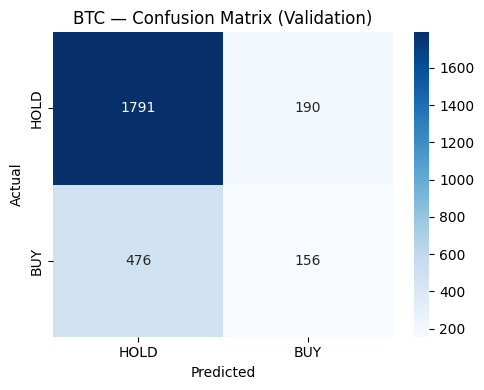

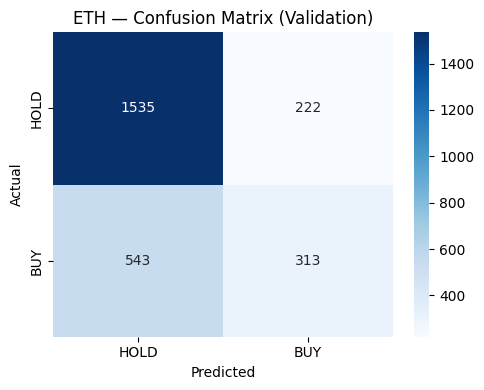

In [8]:
def plot_confusion(y_true, y_pred, name: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["HOLD","BUY"],
        yticklabels=["HOLD","BUY"],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} — Confusion Matrix (Validation)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_confusion.png"), dpi=120)
    plt.show()

plot_confusion(btc["y_val"], btc_val_results["y_pred"], "BTC")
plot_confusion(eth["y_val"], eth_val_results["y_pred"], "ETH")

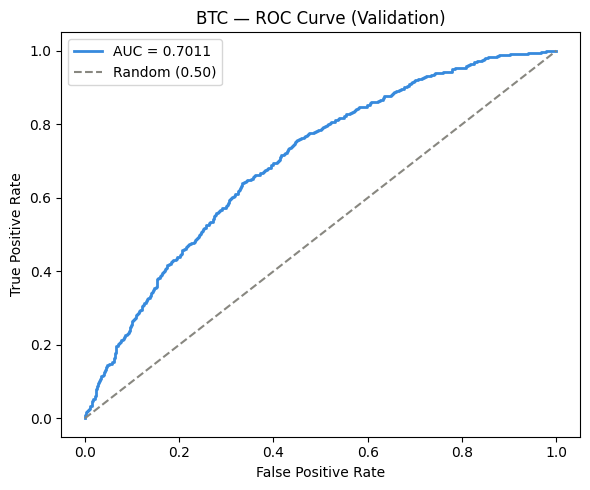

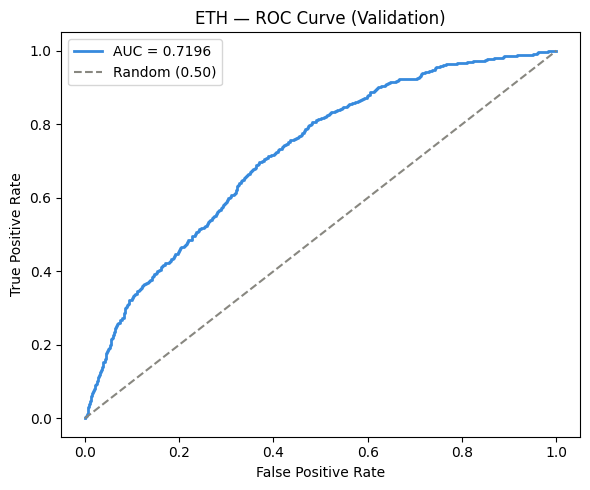

In [ ]:
#9
def plot_roc(y_true, y_prob, name: str, auc: float):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="#378ADD", linewidth=2, label=f"AUC = {auc:.4f}")
    ax.plot([0,1], [0,1], color="#888780", linestyle="--", label="Random (0.50)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} — ROC Curve (Validation)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_roc.png"), dpi=120)
    plt.show()

plot_roc(btc["y_val"], btc_val_results["y_prob"], "BTC", btc_val_results["auc"])
plot_roc(eth["y_val"], eth_val_results["y_prob"], "ETH", eth_val_results["auc"])

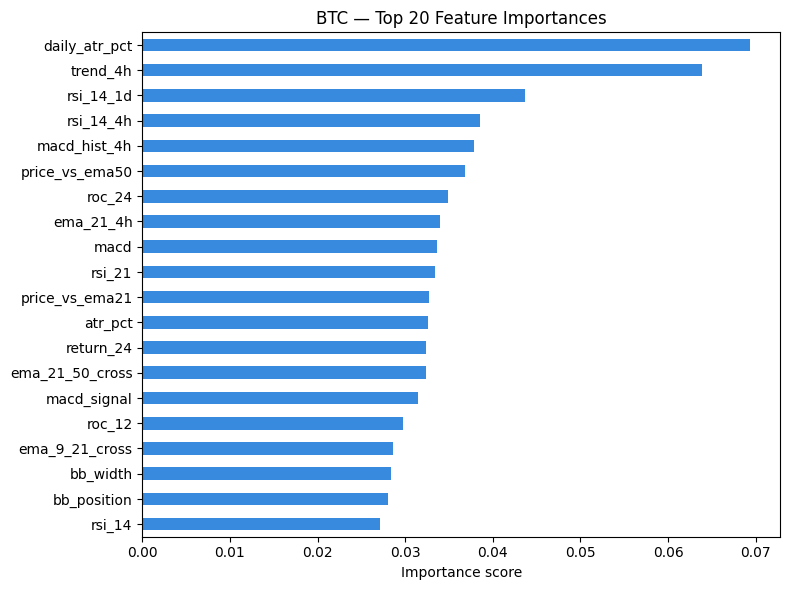


Top 5 most important features for BTC:
daily_atr_pct    0.069303
trend_4h         0.063832
rsi_14_1d        0.043676
rsi_14_4h        0.038522
macd_hist_4h     0.037810


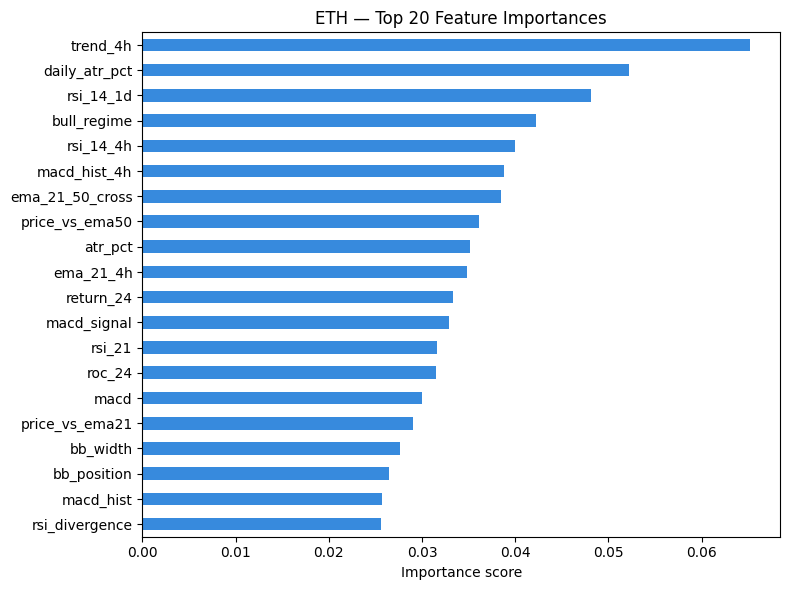


Top 5 most important features for ETH:
trend_4h         0.065148
daily_atr_pct    0.052156
rsi_14_1d        0.048093
bull_regime      0.042207
rsi_14_4h        0.039975


In [10]:
def plot_feature_importance(model, feature_cols: list, name: str, top_n: int = 20):
    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    importance.plot(kind="barh", ax=ax, color="#378ADD")
    ax.set_title(f"{name} — Top {top_n} Feature Importances")
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"{name.lower()}_feature_importance.png"), dpi=120)
    plt.show()

    print(f"\nTop 5 most important features for {name}:")
    print(importance.tail(5).sort_values(ascending=False).to_string())

plot_feature_importance(btc_xgb, feature_cols, "BTC")
plot_feature_importance(eth_xgb, feature_cols, "ETH")

In [ ]:
#11
# LightGBM is often faster and sometimes more accurate than XGBoost.
# We train both and keep whichever scores higher on validation F1.

def train_lgb(data: dict, scale_pos_weight: float, name: str):
    print(f"\nTraining LightGBM for {name}...")

    model = lgb.LGBMClassifier(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1
    )

    model.fit(
        data["X_train"], data["y_train"],
        eval_set            = [(data["X_val"], data["y_val"])],
        callbacks           = [lgb.early_stopping(30), lgb.log_evaluation(50)]
    )

    return model

btc_lgb = train_lgb(btc, btc_spw, "BTC")
eth_lgb = train_lgb(eth, eth_spw, "ETH")

# Evaluate LightGBM
btc_lgb_results = evaluate(btc_lgb, btc, "BTC-LGB")
eth_lgb_results = evaluate(eth_lgb, eth, "ETH-LGB")


Training LightGBM for BTC...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.537709
[100]	valid_0's binary_logloss: 0.520278
[150]	valid_0's binary_logloss: 0.513287
Early stopping, best iteration is:
[151]	valid_0's binary_logloss: 0.513214

Training LightGBM for ETH...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.592814
[100]	valid_0's binary_logloss: 0.577802
[150]	valid_0's binary_logloss: 0.574229
Early stopping, best iteration is:
[147]	valid_0's binary_logloss: 0.573344


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  BTC-LGB | VAL SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.79      0.90      0.84      1981
         BUY       0.46      0.26      0.33       632

    accuracy                           0.75      2613
   macro avg       0.62      0.58      0.59      2613
weighted avg       0.71      0.75      0.72      2613

  F1        : 0.3279
  Precision : 0.4551  ← of all BUY signals, how many were right?
  Recall    : 0.2563  ← of all real BUY moves, how many did we catch?
  ROC-AUC   : 0.7078  ← 0.5=random, 1.0=perfect, >0.55 is useful


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  ETH-LGB | VAL SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.73      0.86      0.79      1757
         BUY       0.54      0.33      0.41       856

    accuracy                           0.69      2613
   macro avg       0.63      0.60      0.60      2613
weighted avg       0.67      0.69      0.67      2613

  F1        : 0.4127
  Precision : 0.5429  ← of all BUY signals, how many were right?
  Recall    : 0.3329  ← of all real BUY moves, how many did we catch?
  ROC-AUC   : 0.7116  ← 0.5=random, 1.0=perfect, >0.55 is useful


In [12]:
print("\n" + "="*50)
print("  MODEL COMPARISON — VALIDATION F1")
print("="*50)
print(f"  BTC XGBoost  F1  : {btc_val_results['f1']:.4f}   AUC: {btc_val_results['auc']:.4f}")
print(f"  BTC LightGBM F1  : {btc_lgb_results['f1']:.4f}   AUC: {btc_lgb_results['auc']:.4f}")
print()
print(f"  ETH XGBoost  F1  : {eth_val_results['f1']:.4f}   AUC: {eth_val_results['auc']:.4f}")
print(f"  ETH LightGBM F1  : {eth_lgb_results['f1']:.4f}   AUC: {eth_lgb_results['auc']:.4f}")

# Pick the better model for each asset
btc_best = btc_xgb if btc_val_results["f1"] >= btc_lgb_results["f1"] else btc_lgb
eth_best = eth_xgb if eth_val_results["f1"] >= eth_lgb_results["f1"] else eth_lgb

btc_best_name = "XGBoost" if btc_val_results["f1"] >= btc_lgb_results["f1"] else "LightGBM"
eth_best_name = "XGBoost" if eth_val_results["f1"] >= eth_lgb_results["f1"] else "LightGBM"

print(f"\n  Winner BTC: {btc_best_name}")
print(f"  Winner ETH: {eth_best_name}")


  MODEL COMPARISON — VALIDATION F1
  BTC XGBoost  F1  : 0.3190   AUC: 0.7011
  BTC LightGBM F1  : 0.3279   AUC: 0.7078

  ETH XGBoost  F1  : 0.4500   AUC: 0.7196
  ETH LightGBM F1  : 0.4127   AUC: 0.7116

  Winner BTC: LightGBM
  Winner ETH: XGBoost


In [ ]:
#13
# ── Run test evaluation first ──
print("FINAL TEST SET EVALUATION")
print("(These numbers simulate real-world performance)\n")

btc_test_results = evaluate(btc_best, btc, f"BTC ({btc_best_name})", split="test")
eth_test_results = evaluate(eth_best, eth, f"ETH ({eth_best_name})", split="test")

print("\n" + "="*50)
print("  SUMMARY")
print("="*50)
print(f"  BTC test F1  : {btc_test_results['f1']:.4f}")
print(f"  BTC test AUC : {btc_test_results['auc']:.4f}")
print(f"  ETH test F1  : {eth_test_results['f1']:.4f}")
print(f"  ETH test AUC : {eth_test_results['auc']:.4f}")

print("""
  Interpreting results:
  AUC > 0.60  → model has edge, proceed to backtesting
  AUC 0.50–60 → weak signal, go back and improve features
  AUC < 0.50  → model is worse than random, something is wrong
""")

# ── Now save everything ──
def save_model(model, name: str):
    path = os.path.join(MODELS_DIR, f"{name}_best_model.pkl")
    with open(path, "wb") as f:
        pickle.dump(model, f)
    size = os.path.getsize(path) / 1024
    print(f"Saved: {path}  ({size:.1f} KB)")

save_model(btc_best, "btc")
save_model(eth_best, "eth")

summary = {
    "btc_model"    : btc_best_name,
    "eth_model"    : eth_best_name,
    "btc_val_f1"   : btc_val_results["f1"],
    "btc_test_f1"  : btc_test_results["f1"],
    "btc_test_auc" : btc_test_results["auc"],
    "eth_val_f1"   : eth_val_results["f1"],
    "eth_test_f1"  : eth_test_results["f1"],
    "eth_test_auc" : eth_test_results["auc"],
}

summary_path = os.path.join(MODELS_DIR, "phase3_summary.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(summary, f)

print("\nAll models and summary saved.")
print(f"Saved to: {MODELS_DIR}")

FINAL TEST SET EVALUATION
(These numbers simulate real-world performance)


  BTC (LightGBM) | TEST SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.79      0.87      0.83      1917
         BUY       0.51      0.36      0.42       697

    accuracy                           0.74      2614
   macro avg       0.65      0.62      0.62      2614
weighted avg       0.71      0.74      0.72      2614

  F1        : 0.4202
  Precision : 0.5071  ← of all BUY signals, how many were right?
  Recall    : 0.3587  ← of all real BUY moves, how many did we catch?
  ROC-AUC   : 0.7256  ← 0.5=random, 1.0=perfect, >0.55 is useful


C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  ETH (XGBoost) | TEST SET RESULTS
              precision    recall  f1-score   support

        HOLD       0.79      0.75      0.77      1803
         BUY       0.50      0.55      0.52       810

    accuracy                           0.69      2613
   macro avg       0.64      0.65      0.64      2613
weighted avg       0.70      0.69      0.69      2613

  F1        : 0.5200
  Precision : 0.4955  ← of all BUY signals, how many were right?
  Recall    : 0.5469  ← of all real BUY moves, how many did we catch?
  ROC-AUC   : 0.7087  ← 0.5=random, 1.0=perfect, >0.55 is useful

  SUMMARY
  BTC test F1  : 0.4202
  BTC test AUC : 0.7256
  ETH test F1  : 0.5200
  ETH test AUC : 0.7087

  Interpreting results:
  AUC > 0.60  → model has edge, proceed to backtesting
  AUC 0.50–60 → weak signal, go back and improve features
  AUC < 0.50  → model is worse than random, something is wrong

Saved: ./data/models\btc_best_model.pkl  (508.8 KB)
Saved: ./data/models\eth_best_model.pkl  (675.4 KB)

Al

In [14]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(model, data: dict, name: str):
    """
    Default threshold is 0.50. Raising it increases precision
    (fewer false BUY signals) at the cost of recall.
    For trading we want precision > 0.55 minimum.
    """
    y_prob = model.predict_proba(data["X_val"])[:, 1]
    y_true = data["y_val"]

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    print(f"\n{name} — Threshold Analysis:")
    print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 45)

    for thresh in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
        y_pred = (y_prob >= thresh).astype(int)
        if y_pred.sum() == 0:
            continue
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        signals = y_pred.sum()
        print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}  ({signals} signals)")

find_best_threshold(btc_best, btc, "BTC")
find_best_threshold(eth_best, eth, "ETH")

C:\Users\wizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



BTC — Threshold Analysis:
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.40      0.434      0.429      0.431  (625 signals)
      0.45      0.450      0.339      0.386  (476 signals)
      0.50      0.455      0.256      0.328  (356 signals)
      0.55      0.474      0.187      0.268  (249 signals)
      0.60      0.494      0.134      0.211  (172 signals)
      0.65      0.526      0.095      0.161  (114 signals)
      0.70      0.556      0.063      0.114  (72 signals)

ETH — Threshold Analysis:
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.40      0.498      0.527      0.512  (905 signals)
      0.45      0.531      0.435      0.478  (700 signals)
      0.50      0.585      0.366      0.450  (535 signals)
      0.55      0.626      0.287      0.394  (393 signals)
      0.60      0.646      0.220      0.328  (291 signals)
      0.65      0.644      0.157      0.252  (208 signals)
